In [23]:
from orderbook import gparseL3, aSnapL3, aBidAsk, TOrderlog
import zstandard as zstd
import numpy as np
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [2]:
def read(fname, dtype=TOrderlog):
    with open(fname, 'rb') as f:
        r = zstd.ZstdDecompressor().stream_reader(f)
        buf = r.readall()
        return np.frombuffer(buf, dtype=dtype)

In [3]:
f = read('../../data/fut/xeur-eobi-20260309.mbo.zst')
len(f)

2232542

In [12]:
L = f[f['instrument_id'] == 442]
len(f)

2030293

In [13]:
S = np.fromiter(tqdm(gparseL3(L, aBidAsk()), total=len(L)), dtype=[('Bid', 'f8'), ('Ask', 'f8')])
S

  0%|          | 0/2030293 [00:00<?, ?it/s]

array([(1.1528, 1.1532), (1.1528, 1.1533), (1.1528, 1.1532), ...,
       (1.1638, 1.1642), (1.1638, 1.1642), (1.1635, 1.1641)],
      dtype=[('Bid', '<f8'), ('Ask', '<f8')])

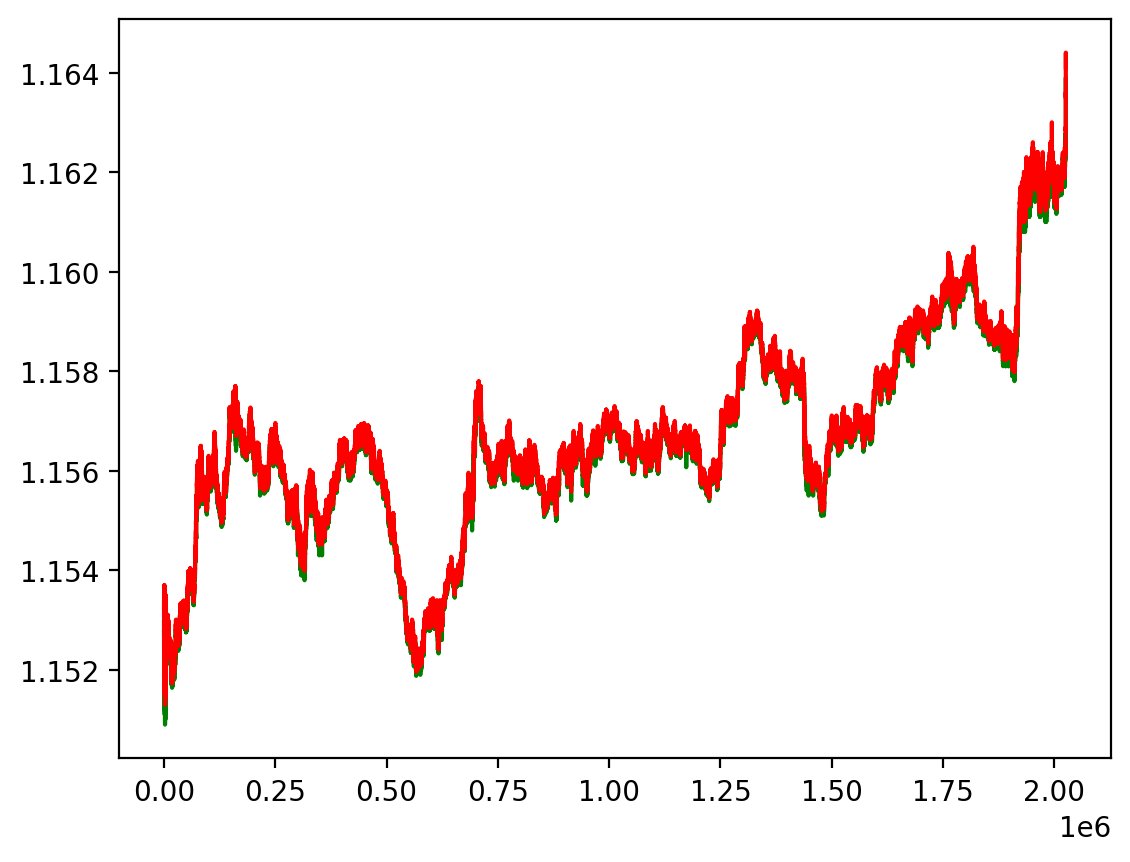

In [28]:
plt.plot(S['Bid'], color='green');
plt.plot(S['Ask'], color='red');

In [20]:
c = 0
for ask, bid in tqdm(gparseL3(L, aSnapL3()), total=len(L)):
    c += 1
    if c > 1000000:
        break

ask

  0%|          | 0/2030293 [00:00<?, ?it/s]

{1.15686: {10996426590562660297: 20},
 1.15685: {10996426590593343084: 20},
 1.15684: {10996426590580560910: 30},
 1.1567: {10996426569050923873: 20}}

In [21]:
bid

{1.15693: {1773054553725736090: 20},
 1.15694: {1773054553725785102: 30},
 1.157: {1773054520190576543: 20}}